# Lab 1 â€” Model Comparison

Side-by-side evaluation of all four sentiment classifiers â€” **ANN**, **BiLSTM**, **DistilBERT**, and **RoBERTa** â€” across three datasets of increasing scale and complexity.

| Dataset | Task | Test samples |
|---------|------|--------------|
| 1K | Binary sentiment (Negative / Positive) | 100 |
| 25K | Binary sentiment (Negative / Positive) | 2 500 |
| Video Games (VG) | 5-class star rating (1â€“5) | ~256 K |

Each dataset section shows per-model classification reports, a comparison table (Accuracy, Macro F1, Weighted F1), and confusion matrices. An overall summary table at the end collects all 12 results.

## Setup & Imports

In [ ]:
import contextlib
import io

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from data_loading_code import preprocess_pandas
from transformer_utils import (
    build_tf_datasets,
    compute_metrics_tf,
    evaluate_tf,
    plot_confusion_matrix_tf,
)
from utils import (
    device_check,
    validate,
    plot_confusion_matrix,
    load_ann_run,
    load_bilstm_run,
)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR  = NOTEBOOK_DIR.parent
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
MODELS_DIR   = PROJECT_DIR / 'models'
MAX_LENGTH   = 128

DISTILBERT_NAME = 'distilbert-base-uncased'
ROBERTA_NAME    = 'roberta-base'

tokenizer_distilbert = AutoTokenizer.from_pretrained(DISTILBERT_NAME)
tokenizer_roberta    = AutoTokenizer.from_pretrained(ROBERTA_NAME)

In [3]:
test_1k  = pd.read_csv(SPLITS_DIR / '1k_test.csv')
test_25k = pd.read_csv(SPLITS_DIR / '25k_test.csv')
test_vg  = pd.read_csv(SPLITS_DIR / 'vg_test.csv')
# Remap VG labels 1-5 -> 0-4
test_vg['Class'] = test_vg['Class'].astype(int) - 1

## Helper functions

Preprocessing, encoding, and evaluation wrappers so each dataset section stays concise.

In [4]:
def preprocess_seq(df: pd.DataFrame) -> pd.DataFrame:
    """Lightweight text cleaning for the BiLSTM (keeps stopwords)."""
    df = df.copy()
    s = df['Sentence'].str.lower()
    s = s.str.replace(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', '', regex=True)
    s = s.str.replace(r'(?:\d{1,3}\.){3}\d{1,3}', '', regex=True)
    s = s.str.replace(r'[^\w\s]', ' ', regex=True)
    s = s.str.replace(r'\d+', ' ', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    df['Sentence'] = s
    return df


def encode_corpus(texts, vocab, max_len):
    return torch.tensor(
        [vocab.encode(t, max_len) for t in texts],
        dtype=torch.long,
    )


def eval_ann(model, vectorizer, svd, test_df, batch_size=512):
    """Preprocess Ã¢â€ â€™ TF-IDF Ã¢â€ â€™ SVD Ã¢â€ â€™ DataLoader Ã¢â€ â€™ validate. Returns (y_true, y_pred)."""
    test_proc = preprocess_pandas(test_df.copy())
    X_tfidf   = vectorizer.transform(test_proc['Sentence'])
    X_svd     = svd.transform(X_tfidf)
    X_t       = torch.tensor(X_svd, dtype=torch.float32)
    y_t       = torch.tensor(test_df['Class'].values, dtype=torch.long)
    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    _, _, y_true, y_pred = validate(model, loader, nn.CrossEntropyLoss())
    return y_true, y_pred


def eval_bilstm(model, vocab, max_seq_len, test_df, batch_size=512):
    """Preprocess Ã¢â€ â€™ encode Ã¢â€ â€™ DataLoader Ã¢â€ â€™ validate. Returns (y_true, y_pred)."""
    test_proc = preprocess_seq(test_df.copy())
    X_t       = encode_corpus(test_proc['Sentence'].tolist(), vocab, max_seq_len)
    y_t       = torch.tensor(test_df['Class'].values, dtype=torch.long)
    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    _, _, y_true, y_pred = validate(model, loader, nn.CrossEntropyLoss())
    return y_true, y_pred


def report(label, y_true, y_pred, class_names):
    """Print a sklearn classification report."""
    print(f"Classification Report: {label}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))


def compute_scores(name, y_true, y_pred):
    return {
        'Model':       name,
        'Accuracy':    accuracy_score(y_true, y_pred),
        'Macro F1':    f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def get_trainer(model):
    args = TrainingArguments(
        output_dir='tmp_eval',
        per_device_eval_batch_size=64,
        dataloader_num_workers=4,
        report_to='none',
    )
    return Trainer(model=model, args=args, compute_metrics=compute_metrics_tf)




def show_cm_grid(specs, ncols=2):
    """Display confusion matrices in a grid, preserving vector (SVG) quality.

    Intercepts plt.show, captures each figure as SVG, then lays them out
    in an HTML flexbox grid — no rasterization, no blurring.

    specs : list of tuples passed straight to plot_confusion_matrix_tf:
            (y_true, y_pred, num_classes, class_names, title[, normalize])
    """
    import io
    import re as _re
    from IPython.display import HTML, display as ipy_display

    original_show = plt.show
    svgs = []

    def _capture():
        buf = io.BytesIO()
        plt.savefig(buf, format='svg', bbox_inches='tight')
        buf.seek(0)
        svg = buf.getvalue().decode('utf-8')
        # Strip fixed width/height so the SVG scales with its container
        svg = _re.sub(r'(<svg[^>]*) width="[^"]*"',  r'', svg)
        svg = _re.sub(r'(<svg[^>]*) height="[^"]*"', r'', svg)
        svgs.append(svg)
        plt.close()

    plt.show = _capture
    try:
        for spec in specs:
            plot_confusion_matrix_tf(*spec)
    finally:
        plt.show = original_show

    pct = 100 // ncols
    cells_html = ''.join(
        f'<div style="display:inline-block; width:{pct}%; padding:6px;'
        f' box-sizing:border-box; vertical-align:top;">{svg}</div>'
        for svg in svgs
    )
    ipy_display(HTML(f'<div style="display:flex; flex-wrap:wrap; width:100%;">{cells_html}</div>'))


## Load all models

In [5]:
# ===== ANN =====
ann_model_1k,  ann_vec_1k,  ann_svd_1k  = load_ann_run(MODELS_DIR / 'ann_1k',  device)
ann_model_25k, ann_vec_25k, ann_svd_25k = load_ann_run(MODELS_DIR / 'ann_25k', device)
ann_model_vg,  ann_vec_vg,  ann_svd_vg  = load_ann_run(MODELS_DIR / 'ann_vg',  device)

In [6]:
# ===== BiLSTM =====
bilstm_model_1k,  bilstm_vocab_1k,  bilstm_maxlen_1k  = load_bilstm_run(MODELS_DIR / 'bilstm_1k',  device)
bilstm_model_25k, bilstm_vocab_25k, bilstm_maxlen_25k = load_bilstm_run(MODELS_DIR / 'bilstm_25k', device)
bilstm_model_vg,  bilstm_vocab_vg,  bilstm_maxlen_vg  = load_bilstm_run(MODELS_DIR / 'bilstm_vg',  device)

In [7]:
# ===== DistilBERT =====
distilbert_1k  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'distilbert_1k').to(device)
distilbert_25k = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'distilbert_25k').to(device)
distilbert_vg  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'distilbert_vg').to(device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [8]:
# ===== RoBERTa =====
roberta_1k  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'roberta_1k').to(device)
roberta_25k = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'roberta_25k').to(device)
roberta_vg  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'roberta_vg').to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## Build transformer test datasets

One tokenized dataset per (model family, split). The same test DataFrame is passed
for all three slots â€” only the `'test'` key is used.

In [9]:
def build_test_ds(test_df, tokenizer):
    return build_tf_datasets(
        train_df=test_df, val_df=test_df, test_df=test_df,
        tokenizer=tokenizer, text_col='Sentence', label_col='Class',
        max_length=MAX_LENGTH,
    )['test']

ds_1k_distil   = build_test_ds(test_1k,  tokenizer_distilbert)
ds_25k_distil  = build_test_ds(test_25k, tokenizer_distilbert)
ds_vg_distil   = build_test_ds(test_vg,  tokenizer_distilbert)

ds_1k_roberta  = build_test_ds(test_1k,  tokenizer_roberta)
ds_25k_roberta = build_test_ds(test_25k, tokenizer_roberta)
ds_vg_roberta  = build_test_ds(test_vg,  tokenizer_roberta)

---
# 1K Dataset

All four models trained on the 1 K Amazon review split, evaluated on `1k_test.csv` (100 samples, binary).

In [10]:
CLASS_NAMES_BIN = ['Negative', 'Positive']

# ANN
with contextlib.redirect_stdout(io.StringIO()):
    y_true_ann_1k, y_pred_ann_1k = eval_ann(ann_model_1k, ann_vec_1k, ann_svd_1k, test_1k)

# BiLSTM
with contextlib.redirect_stdout(io.StringIO()):
    y_true_bilstm_1k, y_pred_bilstm_1k = eval_bilstm(bilstm_model_1k, bilstm_vocab_1k, bilstm_maxlen_1k, test_1k)

# DistilBERT
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_distil_1k, y_pred_distil_1k = evaluate_tf(
        get_trainer(distilbert_1k), ds_1k_distil,
        label='DistilBERT — 1K', class_names=CLASS_NAMES_BIN,
    )

# RoBERTa
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_roberta_1k, y_pred_roberta_1k = evaluate_tf(
        get_trainer(roberta_1k), ds_1k_roberta,
        label='RoBERTa — 1K', class_names=CLASS_NAMES_BIN,
    )

Classification Report: ANN â€” 1K

              precision    recall  f1-score   support

    Negative      0.707     0.820     0.759        50
    Positive      0.786     0.660     0.717        50

    accuracy                          0.740       100
   macro avg      0.746     0.740     0.738       100
weighted avg      0.746     0.740     0.738       100

Classification Report: BiLSTM â€” 1K

              precision    recall  f1-score   support

    Negative      0.696     0.780     0.736        50
    Positive      0.750     0.660     0.702        50

    accuracy                          0.720       100
   macro avg      0.723     0.720     0.719       100
weighted avg      0.723     0.720     0.719       100



Classification Report: DistilBERT â€” 1K

              precision    recall  f1-score   support

    Negative      0.940     0.940     0.940        50
    Positive      0.940     0.940     0.940        50

    accuracy                          0.940       100
   macro avg      0.940     0.940     0.940       100
weighted avg      0.940     0.940     0.940       100

Trainer metrics:
  test_loss: 0.2186
  test_model_preparation_time: 0.0016
  test_accuracy: 0.9400
  test_macro_f1: 0.9400
  test_weighted_f1: 0.9400
  test_runtime: 0.4885
  test_samples_per_second: 204.6910
  test_steps_per_second: 4.0940


Classification Report: RoBERTa â€” 1K

              precision    recall  f1-score   support

    Negative      0.979     0.920     0.948        50
    Positive      0.925     0.980     0.951        50

    accuracy                          0.950       100
   macro avg      0.952     0.950     0.950       100
weighted avg      0.952     0.950     0.950       100

Trainer metrics:
  test_loss: 0.1891
  test_model_preparation_time: 0.0043
  test_accuracy: 0.9500
  test_macro_f1: 0.9500
  test_weighted_f1: 0.9500
  test_runtime: 0.5417
  test_samples_per_second: 184.6050
  test_steps_per_second: 3.6920


In [11]:
results_1k = [
    compute_scores('ANN',        y_true_ann_1k,    y_pred_ann_1k),
    compute_scores('BiLSTM',     y_true_bilstm_1k, y_pred_bilstm_1k),
    compute_scores('DistilBERT', y_true_distil_1k, y_pred_distil_1k),
    compute_scores('RoBERTa',    y_true_roberta_1k, y_pred_roberta_1k),
]
df_1k = pd.DataFrame(results_1k).set_index('Model')
df_1k.style.format('{:.4f}').highlight_max(axis=0, props='font-weight: bold; color: #1a7f3c')

,Accuracy,Macro F1,Weighted F1
Model,,,
ANN,0.7400,0.7383,0.7383
BiLSTM,0.7200,0.7190,0.7190
DistilBERT,0.9400,0.9400,0.9400
RoBERTa,0.9500,0.9500,0.9500


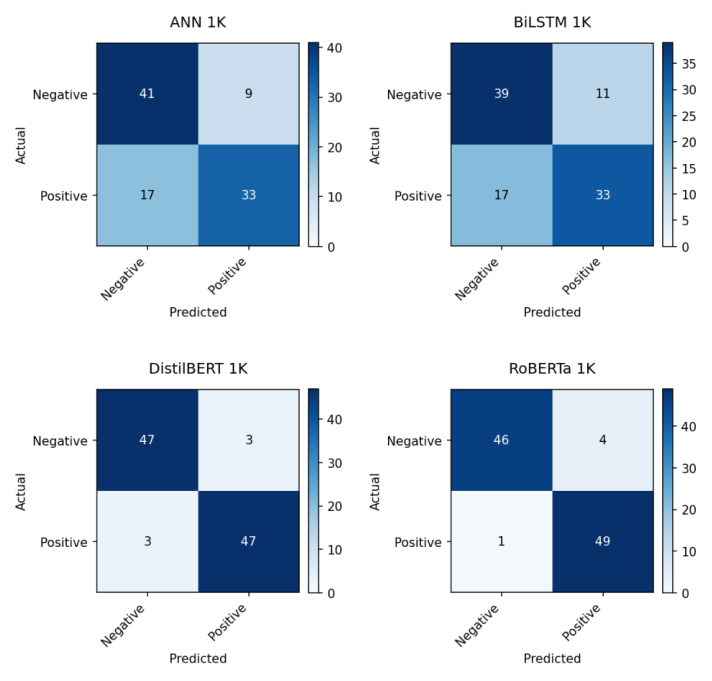

In [12]:
show_cm_grid([
    (y_true_ann_1k,     y_pred_ann_1k,     2, CLASS_NAMES_BIN, 'ANN 1K'),
    (y_true_bilstm_1k,  y_pred_bilstm_1k,  2, CLASS_NAMES_BIN, 'BiLSTM 1K'),
    (y_true_distil_1k,  y_pred_distil_1k,  2, CLASS_NAMES_BIN, 'DistilBERT 1K'),
    (y_true_roberta_1k, y_pred_roberta_1k, 2, CLASS_NAMES_BIN, 'RoBERTa 1K'),
])

---
# 25K Dataset

All four models trained on the 25 K Amazon review split, evaluated on `25k_test.csv` (2 500 samples, binary).

In [13]:

# ANN
with contextlib.redirect_stdout(io.StringIO()):
    y_true_ann_25k, y_pred_ann_25k = eval_ann(ann_model_25k, ann_vec_25k, ann_svd_25k, test_25k)

# BiLSTM
with contextlib.redirect_stdout(io.StringIO()):
    y_true_bilstm_25k, y_pred_bilstm_25k = eval_bilstm(bilstm_model_25k, bilstm_vocab_25k, bilstm_maxlen_25k, test_25k)

# DistilBERT
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_distil_25k, y_pred_distil_25k = evaluate_tf(
        get_trainer(distilbert_25k), ds_25k_distil,
        label='DistilBERT — 25K', class_names=CLASS_NAMES_BIN,
    )

# RoBERTa
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_roberta_25k, y_pred_roberta_25k = evaluate_tf(
        get_trainer(roberta_25k), ds_25k_roberta,
        label='RoBERTa — 25K', class_names=CLASS_NAMES_BIN,
    )

Classification Report: ANN â€” 25K

              precision    recall  f1-score   support

    Negative      0.794     0.821     0.807       988
    Positive      0.880     0.860     0.870      1512

    accuracy                          0.845      2500
   macro avg      0.837     0.841     0.839      2500
weighted avg      0.846     0.845     0.845      2500

Classification Report: BiLSTM â€” 25K

              precision    recall  f1-score   support

    Negative      0.847     0.832     0.839       988
    Positive      0.891     0.901     0.896      1512

    accuracy                          0.874      2500
   macro avg      0.869     0.867     0.868      2500
weighted avg      0.874     0.874     0.874      2500



Classification Report: DistilBERT â€” 25K

              precision    recall  f1-score   support

    Negative      0.908     0.917     0.912       988
    Positive      0.945     0.939     0.942      1512

    accuracy                          0.930      2500
   macro avg      0.927     0.928     0.927      2500
weighted avg      0.931     0.930     0.930      2500

Trainer metrics:
  test_loss: 0.1859
  test_model_preparation_time: 0.0021
  test_accuracy: 0.9304
  test_macro_f1: 0.9273
  test_weighted_f1: 0.9305
  test_runtime: 2.9979
  test_samples_per_second: 833.9250
  test_steps_per_second: 13.3430


Classification Report: RoBERTa â€” 25K

              precision    recall  f1-score   support

    Negative      0.928     0.930     0.929       988
    Positive      0.954     0.953     0.954      1512

    accuracy                          0.944      2500
   macro avg      0.941     0.942     0.941      2500
weighted avg      0.944     0.944     0.944      2500

Trainer metrics:
  test_loss: 0.1716
  test_model_preparation_time: 0.0030
  test_accuracy: 0.9440
  test_macro_f1: 0.9414
  test_weighted_f1: 0.9440
  test_runtime: 5.4404
  test_samples_per_second: 459.5290
  test_steps_per_second: 7.3520


In [14]:
results_25k = [
    compute_scores('ANN',        y_true_ann_25k,    y_pred_ann_25k),
    compute_scores('BiLSTM',     y_true_bilstm_25k, y_pred_bilstm_25k),
    compute_scores('DistilBERT', y_true_distil_25k, y_pred_distil_25k),
    compute_scores('RoBERTa',    y_true_roberta_25k, y_pred_roberta_25k),
]
df_25k = pd.DataFrame(results_25k).set_index('Model')
df_25k.style.format('{:.4f}').highlight_max(axis=0, props='font-weight: bold; color: #1a7f3c')

,Accuracy,Macro F1,Weighted F1
Model,,,
ANN,0.8448,0.8386,0.8452
BiLSTM,0.8740,0.8678,0.8738
DistilBERT,0.9304,0.9273,0.9305
RoBERTa,0.9440,0.9414,0.9440


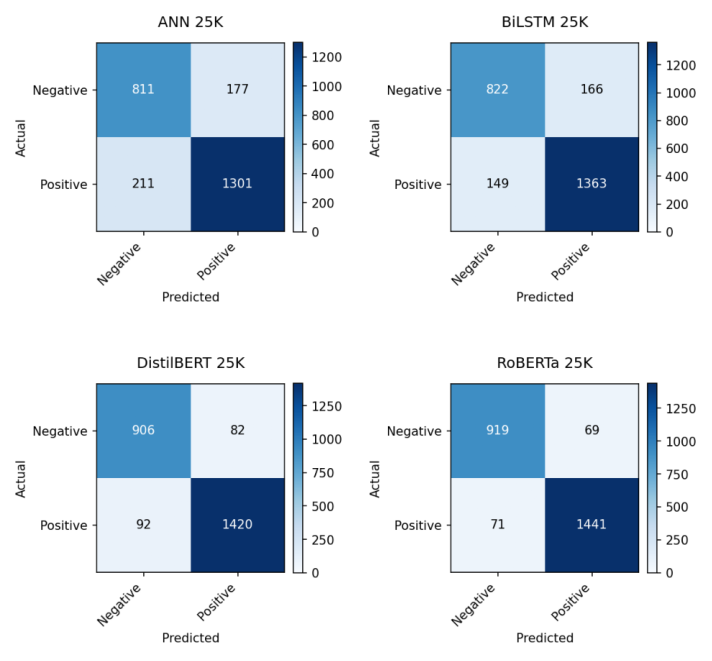

In [15]:
show_cm_grid([
    (y_true_ann_25k,    y_pred_ann_25k,    2, CLASS_NAMES_BIN, 'ANN 25K'),
    (y_true_bilstm_25k, y_pred_bilstm_25k, 2, CLASS_NAMES_BIN, 'BiLSTM 25K'),
    (y_true_distil_25k, y_pred_distil_25k, 2, CLASS_NAMES_BIN, 'DistilBERT 25K'),
    (y_true_roberta_25k, y_pred_roberta_25k, 2, CLASS_NAMES_BIN, 'RoBERTa 25K'),
])

---
# Video Games Dataset

All four models trained on the Video Games split, evaluated on `vg_test.csv` (~256 K samples, 5-class star rating).

In [16]:
CLASS_NAMES_VG = ['1-star', '2-star', '3-star', '4-star', '5-star']

# ANN
with contextlib.redirect_stdout(io.StringIO()):
    y_true_ann_vg, y_pred_ann_vg = eval_ann(ann_model_vg, ann_vec_vg, ann_svd_vg, test_vg)

# BiLSTM
with contextlib.redirect_stdout(io.StringIO()):
    y_true_bilstm_vg, y_pred_bilstm_vg = eval_bilstm(bilstm_model_vg, bilstm_vocab_vg, bilstm_maxlen_vg, test_vg)

# DistilBERT
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_distil_vg, y_pred_distil_vg = evaluate_tf(
        get_trainer(distilbert_vg), ds_vg_distil,
        label='DistilBERT — VG', class_names=CLASS_NAMES_VG,
    )

# RoBERTa
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_roberta_vg, y_pred_roberta_vg = evaluate_tf(
        get_trainer(roberta_vg), ds_vg_roberta,
        label='RoBERTa — VG', class_names=CLASS_NAMES_VG,
    )

Classification Report: ANN â€” VG

              precision    recall  f1-score   support

      1-star      0.635     0.689     0.661     31181
      2-star      0.230     0.448     0.304     14131
      3-star      0.275     0.338     0.303     21230
      4-star      0.347     0.413     0.377     41225
      5-star      0.871     0.703     0.778    148587

    accuracy                          0.610    256354
   macro avg      0.472     0.518     0.485    256354
weighted avg      0.673     0.610     0.634    256354

Classification Report: BiLSTM â€” VG

              precision    recall  f1-score   support

      1-star      0.723     0.733     0.728     31181
      2-star      0.339     0.434     0.381     14131
      3-star      0.362     0.488     0.416     21230
      4-star      0.390     0.472     0.427     41225
      5-star      0.891     0.769     0.825    148587

    accuracy                          0.675    256354
   macro avg      0.541     0.579     0.555    256354
weig

Classification Report: DistilBERT â€” VG

              precision    recall  f1-score   support

      1-star      0.777     0.749     0.763     31181
      2-star      0.371     0.496     0.425     14131
      3-star      0.416     0.519     0.462     21230
      4-star      0.399     0.550     0.463     41225
      5-star      0.909     0.759     0.827    148587

    accuracy                          0.690    256354
   macro avg      0.574     0.615     0.588    256354
weighted avg      0.740     0.690     0.708    256354

Trainer metrics:
  test_loss: 0.9316
  test_model_preparation_time: 0.0015
  test_accuracy: 0.6900
  test_macro_f1: 0.5879
  test_weighted_f1: 0.7084
  test_runtime: 284.3597
  test_samples_per_second: 901.5130
  test_steps_per_second: 14.0880


Classification Report: RoBERTa â€” VG

              precision    recall  f1-score   support

      1-star      0.811     0.723     0.764     31181
      2-star      0.376     0.555     0.449     14131
      3-star      0.438     0.552     0.488     21230
      4-star      0.419     0.544     0.474     41225
      5-star      0.910     0.781     0.840    148587

    accuracy                          0.704    256354
   macro avg      0.591     0.631     0.603    256354
weighted avg      0.751     0.704     0.722    256354

Trainer metrics:
  test_loss: 0.9091
  test_model_preparation_time: 0.0032
  test_accuracy: 0.7043
  test_macro_f1: 0.6031
  test_weighted_f1: 0.7215
  test_runtime: 546.0920
  test_samples_per_second: 469.4340
  test_steps_per_second: 7.3360


In [17]:
results_vg = [
    compute_scores('ANN',        y_true_ann_vg,    y_pred_ann_vg),
    compute_scores('BiLSTM',     y_true_bilstm_vg, y_pred_bilstm_vg),
    compute_scores('DistilBERT', y_true_distil_vg, y_pred_distil_vg),
    compute_scores('RoBERTa',    y_true_roberta_vg, y_pred_roberta_vg),
]
df_vg = pd.DataFrame(results_vg).set_index('Model')
df_vg.style.format('{:.4f}').highlight_max(axis=0, props='font-weight: bold; color: #1a7f3c')

,Accuracy,Macro F1,Weighted F1
Model,,,
ANN,0.6102,0.4847,0.6338
BiLSTM,0.6749,0.5554,0.6910
DistilBERT,0.6900,0.5879,0.7084
RoBERTa,0.7043,0.6031,0.7215


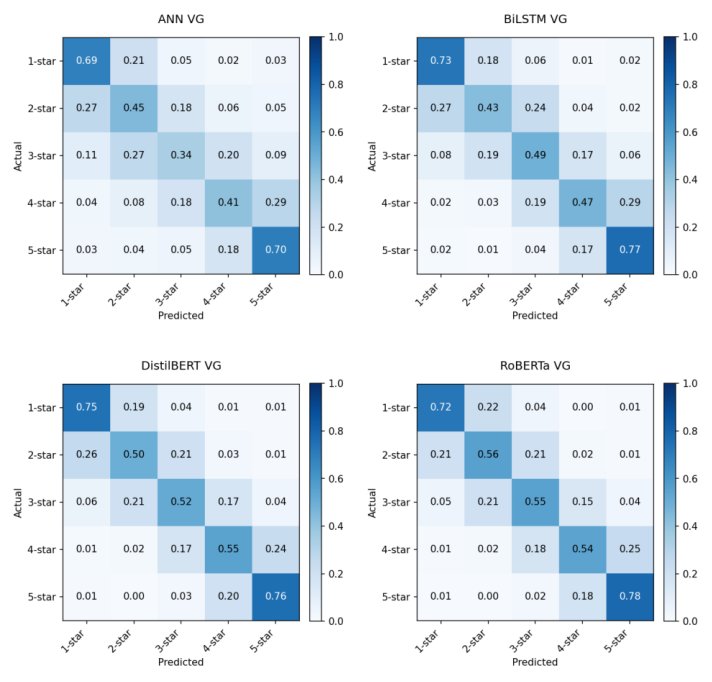

In [18]:
show_cm_grid([
    (y_true_ann_vg,     y_pred_ann_vg,     5, CLASS_NAMES_VG, 'ANN VG',        True),
    (y_true_bilstm_vg,  y_pred_bilstm_vg,  5, CLASS_NAMES_VG, 'BiLSTM VG',     True),
    (y_true_distil_vg,  y_pred_distil_vg,  5, CLASS_NAMES_VG, 'DistilBERT VG', True),
    (y_true_roberta_vg, y_pred_roberta_vg, 5, CLASS_NAMES_VG, 'RoBERTa VG',    True),
])